###### 131_4_practical_monthly_lcm_filter.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)
plt.rcParams["font.family"] = "Meiryo"

In [2]:
df_defect = pd.read_csv("dataset/lcm_monthly_defect_filter.csv")
df_defect

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。


In [3]:
exclude_pattern = r"OLD-110(?!\d)|OLD-220(?!\d)"
exclude_pattern

'OLD-110(?!\\d)|OLD-220(?!\\d)'

In [4]:
df_defect["exclude_flag"] = df_defect["comment"].str.contains(
    exclude_pattern,
    case=False,
    na=False,
    regex=True,
)
df_defect

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。,False
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。,True
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。,False
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。,False
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。,True
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。,False
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。,False
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。,True
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。,False
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。,True


In [5]:
df_defect["exclude_reason"] = ""
df_defect

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag,exclude_reason
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。,False,
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。,True,
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。,False,
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。,False,
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。,True,
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。,False,
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。,False,
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。,True,
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。,False,
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。,True,


In [6]:
df_defect.loc[
    df_defect["comment"].str.contains(
        r"OLD-110(?!\d)",
        case=False,
        na=False,
        regex=True,
    ),
    "exclude_reason",
] = "旧仕様OLD-110"

df_defect

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag,exclude_reason
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。,False,
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。,True,旧仕様OLD-110
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。,False,
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。,False,
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。,True,
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。,False,
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。,False,
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。,True,旧仕様OLD-110
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。,False,
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。,True,


In [7]:
#cell7
df_defect.loc[
    df_defect["comment"].str.contains(
        r"OLD-220(?!\d)",
        case=False,
        na=False,
        regex=True,
    ),
    "exclude_reason",
] = "旧仕様OLD-220"
df_defect

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag,exclude_reason
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。,False,
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。,True,旧仕様OLD-110
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。,False,
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。,False,
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。,True,旧仕様OLD-220
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。,False,
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。,False,
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。,True,旧仕様OLD-110
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。,False,
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。,True,旧仕様OLD-220


In [8]:
df_actual = df_defect[
    ~df_defect["exclude_flag"]
].copy()
df_actual

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag,exclude_reason
0,D001,SUS,Honda,J69P,2026-04,Buck-IC,3,調査中,Buck-ICのHS-FET損傷を確認。現行量産品。,False,
2,D003,WSE,Mitsubishi,310D,2026-04,Coil,2,対策中,コイル内部に鉄粉噛み込みを確認。,False,
3,D004,GSE,Honda,310D,2026-05,NTF,1,調査中,市場返却品を確認したが不具合再現せず。,False,
5,D006,WSE,Honda,310D,2026-05,Coil,3,対策済,160Vインパルス検査で異常検出。,False,
6,D007,SUS,Mitsubishi,J69P,2026-06,NTF,1,調査中,現品確認の結果、症状再現せず。,False,
8,D009,MELMB,Honda,310D,2026-06,Buck-IC,5,調査中,Buck-IC再発疑いとして調査中。,False,
10,D011,SUS,Honda,310D,2026-07,Coil,2,対策中,コイル端子部に変色あり。,False,
11,D012,MELMB,Honda,J69P,2026-07,NTF,1,調査中,ユーザー申告のみで現象確認できず。,False,
12,D013,GSE,Mitsubishi,310D,2026-07,Buck-IC,2,調査中,OLD-1100系ではなく現行品でのBuck-IC異常。,False,
13,D014,WSE,Honda,310D,2026-07,Coil,2,対策中,220V印加試験後に外観異常を確認。,False,


In [9]:
df_exclude = df_defect[
    df_defect["exclude_flag"]
].copy()
df_exclude

,defect_id,site,customer,model,occ_month,defect_category,defect_qty,cm_status,comment,exclude_flag,exclude_reason
1,D002,SUS,Honda,J69P,2026-04,Coil,1,対象外,旧仕様OLD-110で発生した切替前データ。,True,旧仕様OLD-110
4,D005,MELMB,Honda,J69P,2026-05,Buck-IC,4,対象外,OLD-220使用時の参考登録データ。,True,旧仕様OLD-220
7,D008,GSE,Honda,310D,2026-06,Coil,2,対象外,旧仕様OLD-110からの切替前データ。,True,旧仕様OLD-110
9,D010,WSE,Mitsubishi,J69P,2026-06,Coil,1,対象外,OLD-220評価時のメモ。,True,旧仕様OLD-220
14,D015,SUS,Honda,J69P,2026-07,Buck-IC,1,対象外,old-220の過去評価データとして登録。,True,旧仕様OLD-220


In [16]:
total_count = len(df_defect)
print(total_count)
excluded_count = len(df_exclude)
print(excluded_count)
actual_count = len(df_actual)
print(actual_count)

exclude_rate = round(
    excluded_count / total_count * 100,
    1,
)
exclude_rate

df_summary_check = pd.DataFrame(
    {
        "item": [
            "除外前の全件数",
            "除外された件数",
            "正式集計対象の件数",
            "除外率",
        ],
        "value":[
            total_count,
            excluded_count,
            actual_count,
            exclude_rate,
        ]
    }
)
df_summary_check

16
5
11


,item,value
0,除外前の全件数,16.0
1,除外された件数,5.0
2,正式集計対象の件数,11.0
3,除外率,31.2


In [17]:
df_month_qty = df_actual.groupby(
    "occ_month",
    as_index=False,
)["defect_qty"].sum()
df_month_qty

,occ_month,defect_qty
0,2026-04,5
1,2026-05,4
2,2026-06,6
3,2026-07,10


In [18]:
df_month_qty = df_month_qty.rename(
    columns={
        "defect_qty": "actual_defect_qty",
    }
)
df_month_qty

,occ_month,actual_defect_qty
0,2026-04,5
1,2026-05,4
2,2026-06,6
3,2026-07,10


In [19]:
df_month_qty = df_month_qty.sort_values(
    "occ_month",
).reset_index(drop=True)
df_month_qty

,occ_month,actual_defect_qty
0,2026-04,5
1,2026-05,4
2,2026-06,6
3,2026-07,10


In [22]:
df_site_qty = df_actual.groupby(
    "site",
    as_index=False,
)["defect_qty"].sum()
df_site_qty

,site,defect_qty
0,GSE,3
1,MELMB,9
2,SUS,6
3,WSE,7


In [23]:
df_site_qty = df_site_qty.rename(
    columns={
        "defect_qty": "actual_defect_qty",
    }
)
df_site_qty

,site,actual_defect_qty
0,GSE,3
1,MELMB,9
2,SUS,6
3,WSE,7


In [24]:
df_site_qty = df_site_qty.sort_values(
    ["actual_defect_qty", "site"],
    ascending=[False, True],
).reset_index(drop=True)
df_site_qty

,site,actual_defect_qty
0,MELMB,9
1,WSE,7
2,SUS,6
3,GSE,3


In [25]:
df_exclude_check = df_exclude[
    [
        "defect_id",
        "site",
        "occ_month",
        "defect_category",
        "defect_qty",
        "exclude_reason",
        "comment",
    ]
].copy()
df_exclude_check

,defect_id,site,occ_month,defect_category,defect_qty,exclude_reason,comment
1,D002,SUS,2026-04,Coil,1,旧仕様OLD-110,旧仕様OLD-110で発生した切替前データ。
4,D005,MELMB,2026-05,Buck-IC,4,旧仕様OLD-220,OLD-220使用時の参考登録データ。
7,D008,GSE,2026-06,Coil,2,旧仕様OLD-110,旧仕様OLD-110からの切替前データ。
9,D010,WSE,2026-06,Coil,1,旧仕様OLD-220,OLD-220評価時のメモ。
14,D015,SUS,2026-07,Buck-IC,1,旧仕様OLD-220,old-220の過去評価データとして登録。


In [26]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

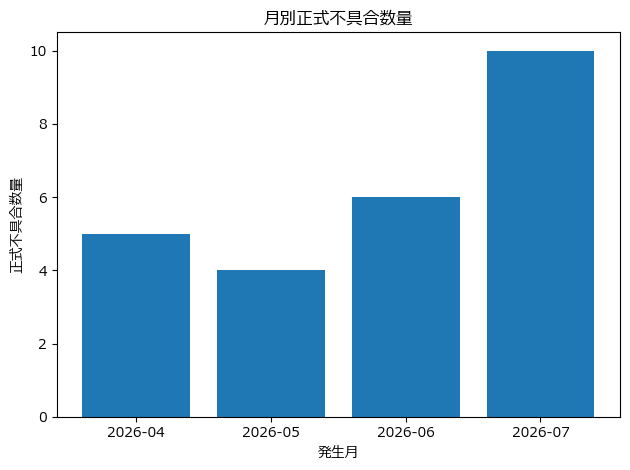

In [32]:
plt.bar(
    df_month_qty["occ_month"],
    df_month_qty["actual_defect_qty"],
)

plt.title("月別正式不具合数量")
plt.xlabel("発生月")
plt.ylabel("正式不具合数量")

plt.tight_layout()
plt.show()